In [48]:
# needed libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

**The problem, restated:** solve
$$\ddot\phi = -\frac{g}{R}\sin\phi, \qquad R = 5\text{ m},\ g = 9.8\text{ m/s}^2$$
numerically with `odeint`, and compare it against the small-angle solution
$$\phi(t) = \phi_0 \cos\!\left(\sqrt{g/R}\, t\right)$$
for **(a)** $\phi_0 = 15°,\ \dot\phi_0 = 0$ and **(b)** $\phi_0 = 90°,\ \dot\phi_0 = 0$.

In [49]:
# setting up the ode

def pendulum(y, t, R = 5, g = 9.8):
    phi = y[0]
    omega = y[1]
    dphi_dt = omega
    domega_dt = (-g/R) * np.sin(phi)

    return [dphi_dt, domega_dt]


In [50]:
# intial conditions
# # cases
def cases(part):
    if part.lower() == "a":
        phi0 = np.deg2rad(15)
        phidot0 = 0
    elif part.lower() == "b":
        phi0 = np.deg2rad(90)
        phidot0 = 0
    else: raise TypeError("Not an option")
    y0 = phi0, phidot0
    return y0

part = input("Enter which part")

y0 = cases(part)

dt = 0.25
tspan = np.arange(0, 10+dt, dt)


In [51]:
# solution
sol = odeint(pendulum, y0, tspan)
phi = sol[:, 0]
dphi_dt = sol[:, 1]

In [52]:
# hand approx. solution
phi0 = y0[0]
def hand(t, R = 5, g = 9.8):
    phi_hand = phi0 * np.cos(np.sqrt(g/R)*t)
    return phi_hand
phi_small = hand(tspan)

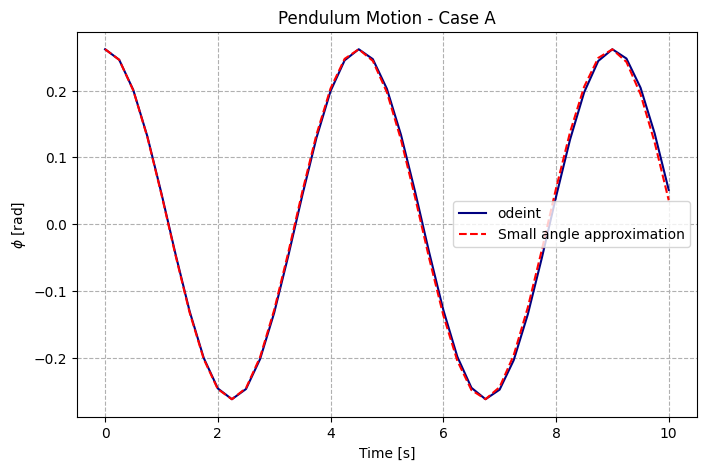

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(tspan, phi, label="odeint", color = "navy")
plt.plot(tspan, phi_small, "--", label="Small angle approximation", color = "red")

plt.xlabel("Time [s]")
plt.ylabel(r"$\phi$ [rad]")
plt.title(f"Pendulum Motion - Case {part.upper()}")

plt.grid(ls = "--")
plt.legend()

plt.show()

In [54]:
def problem_four(part):
    # Constants
    R = 5
    g = 9.8

    # Pendulum ODE system
    def pendulum(y, t):
        phi, omega = y

        dphi_dt = omega
        domega_dt = -(g / R) * np.sin(phi)

        return [dphi_dt, domega_dt]

    # Initial conditions
    if part.lower() == "a":
        phi0 = np.deg2rad(15)
        omega0 = 0

    elif part.lower() == "b":
        phi0 = np.deg2rad(90)
        omega0 = 0

    else:
        raise ValueError("Part must be 'a' or 'b'.")

    y0 = [phi0, omega0]

    # Time interval
    dt = 0.25
    tspan = np.arange(0, 10 + dt, dt)

    # Numerical solution
    sol = odeint(pendulum, y0, tspan)

    phi = sol[:, 0]
    omega = sol[:, 1]

    # Small-angle approximation
    phi_small = phi0 * np.cos(np.sqrt(g / R) * tspan)

    # Plot
    plt.figure(figsize=(8, 5))

    plt.plot(
        tspan,
        phi,
        label="Numerical solution",
        color="navy"
    )

    plt.plot(
        tspan,
        phi_small,
        "--",
        label="Small-angle approximation",
        color="red"
    )

    plt.xlabel("Time [s]")
    plt.ylabel(r"$\phi$ [rad]")
    plt.title(f"Pendulum Motion - Case {part.upper()}")

    plt.grid(ls="--")
    plt.legend()

    plt.show()

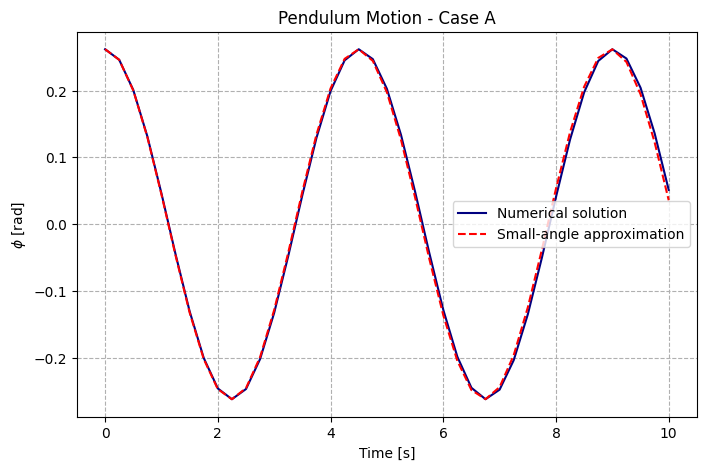

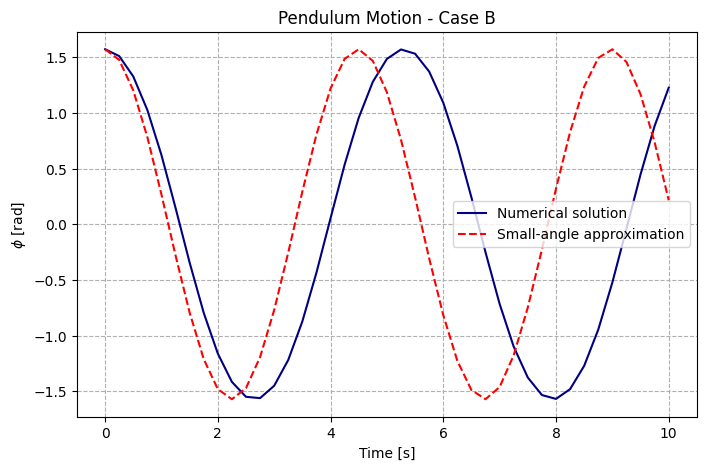

In [ ]:
problem_four("A")
problem_four("B")